# 01 Video Data Exploration

Analyze the video dataset structure, class distribution, and video metadata (FPS, resolution, duration).

In [1]:
import os
import cv2
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm.auto import tqdm

# Paths
DATA_ROOT = Path("../../data/splits/videos")
SPLITS = ["train", "val", "test"]
CLASSES = ["real", "fake"]
VIDEO_EXTENSIONS = {".mp4", ".avi", ".mov"}

print(f"Data Root: {DATA_ROOT.resolve()}")

Data Root: D:\Projects\Machine_Learning Projects\Cognito_AI_A.M\data\splits\videos


## 1. Collect Video Paths

In [2]:
def collect_video_info(root_path):
    data = []
    for split in SPLITS:
        for label in CLASSES:
            folder = root_path / split / label
            if not folder.exists():
                print(f"Warning: {folder} does not exist")
                continue
            
            for video_path in folder.glob("*"):
                if video_path.suffix.lower() in VIDEO_EXTENSIONS:
                    data.append({
                        "path": str(video_path),
                        "split": split,
                        "label": label,
                        "label_id": 1 if label == "fake" else 0
                    })
    return pd.DataFrame(data)

df = collect_video_info(DATA_ROOT)
print(f"Total videos found: {len(df)}")
df.head()

Total videos found: 2259


,path,split,label,label_id
0,..\..\data\splits\videos\train\real\00000.mp4,train,real,0
1,..\..\data\splits\videos\train\real\00003.mp4,train,real,0
2,..\..\data\splits\videos\train\real\00007.mp4,train,real,0
3,..\..\data\splits\videos\train\real\00011.mp4,train,real,0
4,..\..\data\splits\videos\train\real\00019.mp4,train,real,0


## 2. Analyze Class Distribution

Video Distribution:
label  fake  real
split            
test    300    41
train  1394   186
val     298    40


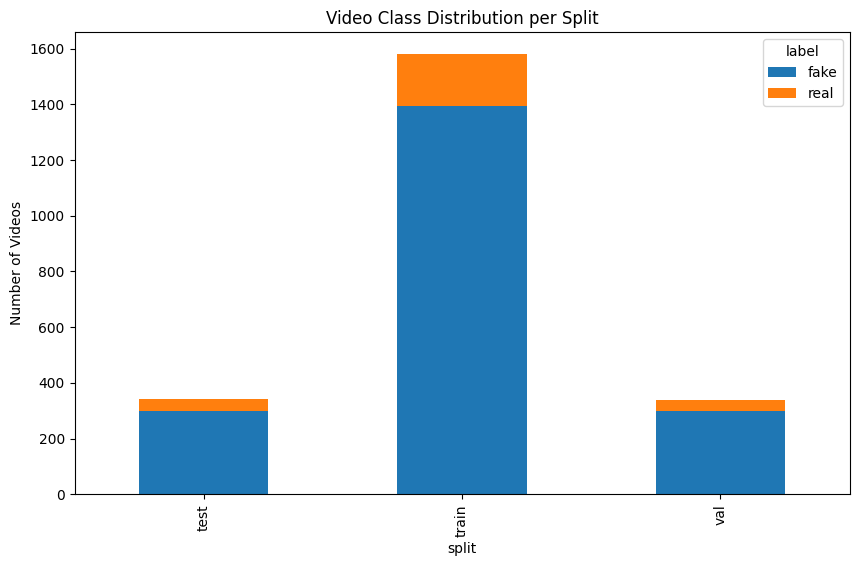

In [3]:
distribution = df.groupby(["split", "label"]).size().unstack(fill_value=0)
print("Video Distribution:")
print(distribution)

distribution.plot(kind="bar", stacked=True, figsize=(10, 6))
plt.title("Video Class Distribution per Split")
plt.ylabel("Number of Videos")
plt.show()

## 3. Extract Metadata (Sampling)

Checking resolution, FPS, and frame counts for a subset of videos.

In [4]:
def get_video_metadata(video_path):
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        return None
    
    fps = cap.get(cv2.CAP_PROP_FPS)
    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    duration = frame_count / fps if fps > 0 else 0
    
    cap.release()
    return {
        "fps": fps,
        "frame_count": frame_count,
        "width": width,
        "height": height,
        "duration": duration
    }

# Sample 10 videos from each class to check consistency
sample_df = df.groupby("label").sample(min(10, len(df)))
metadata_list = []

for idx, row in tqdm(sample_df.iterrows(), total=len(sample_df), desc="Extracting Metadata"):
    meta = get_video_metadata(row["path"])
    if meta:
        meta.update({"label": row["label"]})
        metadata_list.append(meta)

meta_df = pd.DataFrame(metadata_list)
print("\nSample Metadata Summary:")
print(meta_df.describe())

Extracting Metadata:   0%|          | 0/20 [00:00<?, ?it/s]


Sample Metadata Summary:
             fps  frame_count        width       height   duration
count  20.000000    20.000000    20.000000    20.000000  20.000000
mean   29.675001   425.250000   874.400000   512.600000  14.662799
std     1.338056   196.103859   263.304187   134.286575   8.431154
min    24.000000   165.000000   572.000000   456.000000   5.500000
25%    30.000000   313.250000   845.500000   473.500000  10.441667
50%    30.000000   452.500000   850.000000   478.000000  15.083333
75%    30.000000   466.500000   864.000000   500.000000  15.565650
max    30.000000  1140.000000  1920.000000  1080.000000  47.500000


## 4. Visualize Sample Frames

In [ ]:
def plot_sample_frames(df, num_samples=3):
    fig, axes = plt.subplots(len(CLASSES), num_samples, figsize=(15, 10))
    
    for i, label in enumerate(CLASSES):
        subset = df[df["label"] == label].sample(num_samples)
        for j, (idx, row) in enumerate(subset.iterrows()):
            cap = cv2.VideoCapture(row["path"])
            ret, frame = cap.read()
            cap.release()
            
            if ret:
                frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                axes[i, j].imshow(frame)
                axes[i, j].set_title(f"{label}\n{row['path'].split(os.sep)[-1]}")
                axes[i, j].axis("off")
            else:
                axes[i, j].text(0.5, 0.5, "Failed to load", ha="center")
                axes[i, j].axis("off")
    
    plt.tight_layout()
    plt.show()

plot_sample_frames(df)